In [2]:
import os
import json
import random
from pathlib import Path
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2

In [3]:
DATASET_DIR = Path("data/train_data/train_data")

image_paths = sorted(DATASET_DIR.glob("*.png"))
json_paths = sorted(DATASET_DIR.glob("*.json"))

print(f"Images: {len(image_paths)}")
print(f"JSONs : {len(json_paths)}")

Images: 1692
JSONs : 1692


In [4]:
image_ids = {p.stem for p in image_paths}
json_ids = {p.stem for p in json_paths}

missing_json = sorted(image_ids - json_ids)
missing_images = sorted(json_ids - image_ids)

print("Missing JSON:", len(missing_json))
print("Missing images:", len(missing_images))

if missing_json[:10]:
    print("Examples missing JSON:", missing_json[:10])

if missing_images[:10]:
    print("Examples missing images:", missing_images[:10])

Missing JSON: 0
Missing images: 0


In [5]:
def parse_bbox(bbox):
    xs = [
        bbox["top_left"][0],
        bbox["top_right"][0],
        bbox["bottom_left"][0],
        bbox["bottom_right"][0],
    ]
    ys = [
        bbox["top_left"][1],
        bbox["top_right"][1],
        bbox["bottom_left"][1],
        bbox["bottom_right"][1],
    ]
    xmin = min(xs)
    ymin = min(ys)
    xmax = max(xs)
    ymax = max(ys)
    return xmin, ymin, xmax, ymax

rows = []

for json_path in json_paths:
    with open(json_path, "r") as f:
        data = json.load(f)

    xmin, ymin, xmax, ymax = parse_bbox(data["bbox"])

    rows.append({
        "id": data["file_name"],
        "direction": data["walking_into_frame_bool"],
        "xmin": xmin,
        "ymin": ymin,
        "xmax": xmax,
        "ymax": ymax,
        "bbox_width": xmax - xmin,
        "bbox_height": ymax - ymin,
        "cx": (xmin + xmax) / 2,
        "cy": (ymin + ymax) / 2,
        "image_path": str(DATASET_DIR / f"{data['file_name']}.png"),
        "json_path": str(json_path)
    })

df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
df.head()

,id,direction,xmin,ymin,xmax,ymax,bbox_width,bbox_height,cx,cy,image_path,json_path
0,image_0,1,-228.877144,223.618740,-110.614879,416.358789,118.262265,192.740049,-169.746011,319.988765,data\train_data\train_data\image_0.png,data\train_data\train_data\image_0.json
1,image_10,0,-307.385595,215.691074,-243.787758,438.103111,63.597836,222.412037,-275.586677,326.897093,data\train_data\train_data\image_10.png,data\train_data\train_data\image_10.json
2,image_100,1,-253.668909,215.604729,-174.385954,434.196810,79.282955,218.592081,-214.027432,324.900769,data\train_data\train_data\image_100.png,data\train_data\train_data\image_100.json
3,image_1000,0,-234.063807,227.459578,-138.250784,379.189109,95.813023,151.729531,-186.157295,303.324343,data\train_data\train_data\image_1000.png,data\train_data\train_data\image_1000.json
4,image_1001,1,-195.748172,225.637964,-87.976198,392.705318,107.771974,167.067354,-141.862185,309.171641,data\train_data\train_data\image_1001.png,data\train_data\train_data\image_1001.json


In [6]:
sizes = []

for p in image_paths:
    with Image.open(p) as img:
        sizes.append(img.size)

size_counts = pd.Series(sizes).value_counts()
size_counts

(720, 480)    1692
Name: count, dtype: int64

In [7]:
size_map = {}
for p in image_paths:
    with Image.open(p) as img:
        size_map[p.stem] = img.size

df["img_w"] = df["id"].map(lambda x: size_map[x][0])
df["img_h"] = df["id"].map(lambda x: size_map[x][1])

df[["img_w", "img_h"]].drop_duplicates()

,img_w,img_h
0,720,480


In [8]:
invalid = df[
    (df["xmax"] <= df["xmin"]) |
    (df["ymax"] <= df["ymin"]) |
    (~df["direction"].isin([0, 1]))
]

print("Invalid rows:", len(invalid))
invalid.head()

Invalid rows: 0


,id,direction,xmin,ymin,xmax,ymax,bbox_width,bbox_height,cx,cy,image_path,json_path,img_w,img_h


In [9]:
df["direction"].value_counts().sort_index()

direction
0    874
1    818
Name: count, dtype: int64

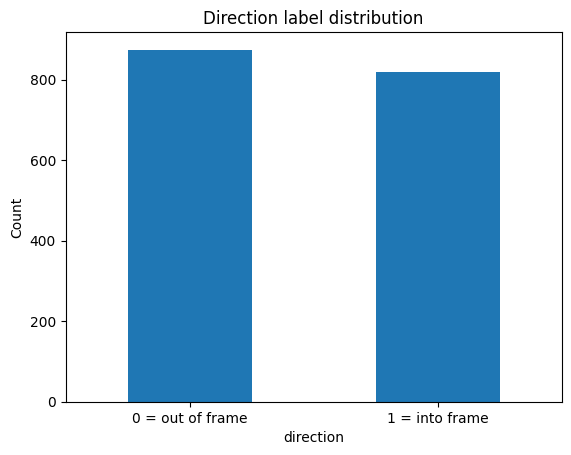

In [10]:
df["direction"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["0 = out of frame", "1 = into frame"], rotation=0)
plt.ylabel("Count")
plt.title("Direction label distribution")
plt.show()

In [11]:
df[["bbox_width", "bbox_height"]].describe()

,bbox_width,bbox_height
count,1692.000000,1692.000000
mean,80.849169,172.898611
std,29.864437,34.684657
min,26.819773,116.498365
25%,57.211529,142.756816
50%,78.568624,169.592696
75%,102.969733,202.409564
max,157.172728,246.902266


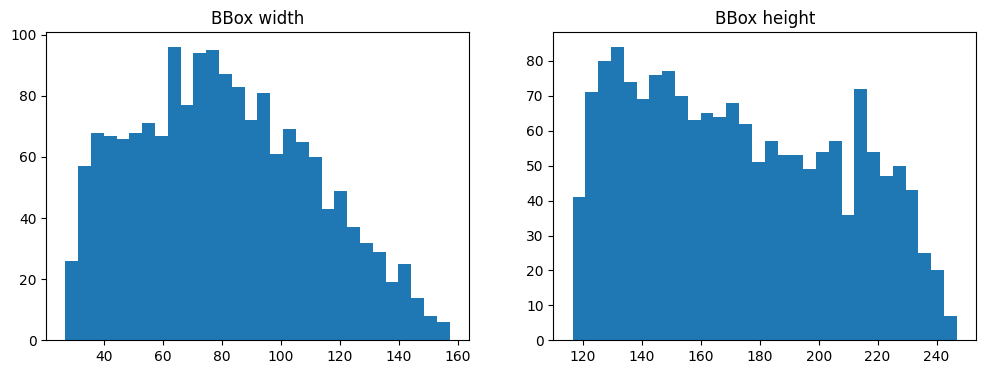

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["bbox_width"], bins=30)
ax[0].set_title("BBox width")

ax[1].hist(df["bbox_height"], bins=30)
ax[1].set_title("BBox height")

plt.show()

In [13]:
def classify_side(row):
    xmin, ymin, xmax, ymax = row["xmin"], row["ymin"], row["xmax"], row["ymax"]
    w, h = row["img_w"], row["img_h"]

    if xmax < 0:
        return "left"
    if xmin > w:
        return "right"
    if ymax < 0:
        return "top"
    if ymin > h:
        return "bottom"

    sides = []
    if xmin < 0:
        sides.append("partly_left")
    if xmax > w:
        sides.append("partly_right")
    if ymin < 0:
        sides.append("partly_top")
    if ymax > h:
        sides.append("partly_bottom")

    return "+".join(sides) if sides else "inside_or_touching"

df["outside_side"] = df.apply(classify_side, axis=1)
df["outside_side"].value_counts()

outside_side
left     852
right    840
Name: count, dtype: int64

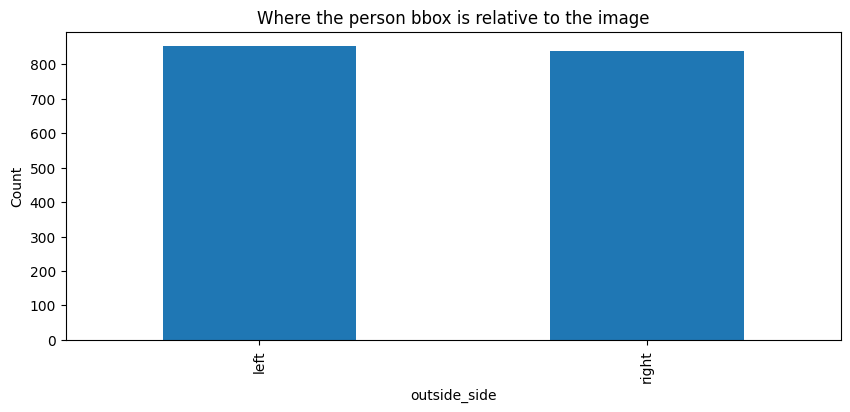

In [14]:
df["outside_side"].value_counts().plot(kind="bar", figsize=(10, 4))
plt.title("Where the person bbox is relative to the image")
plt.ylabel("Count")
plt.show()

In [15]:
def show_extended_sample(row, pad=400):
    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    canvas_h = h + 2 * pad
    canvas_w = w + 2 * pad
    canvas = np.full((canvas_h, canvas_w, 3), 235, dtype=np.uint8)

    canvas[pad:pad+h, pad:pad+w] = img

    xmin = int(round(row["xmin"])) + pad
    ymin = int(round(row["ymin"])) + pad
    xmax = int(round(row["xmax"])) + pad
    ymax = int(round(row["ymax"])) + pad

    cv2.rectangle(canvas, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    plt.figure(figsize=(12, 7))
    plt.imshow(canvas)
    plt.title(f"{row['id']} | direction={row['direction']} | side={row['outside_side']}")
    plt.axis("off")
    plt.show()

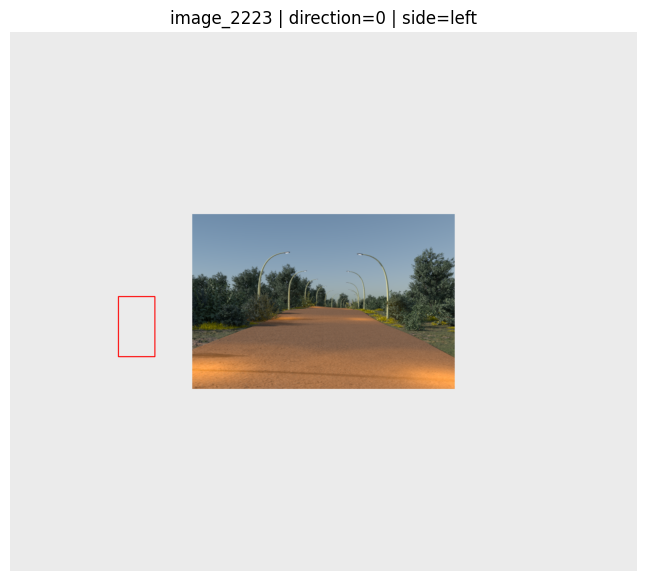

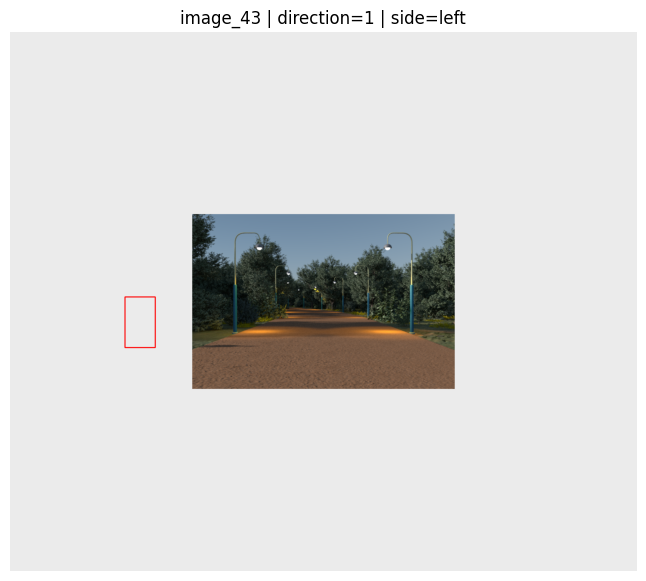

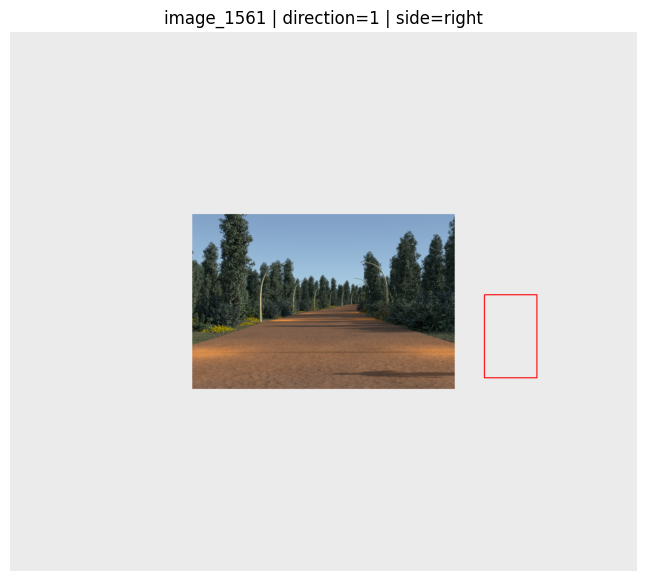

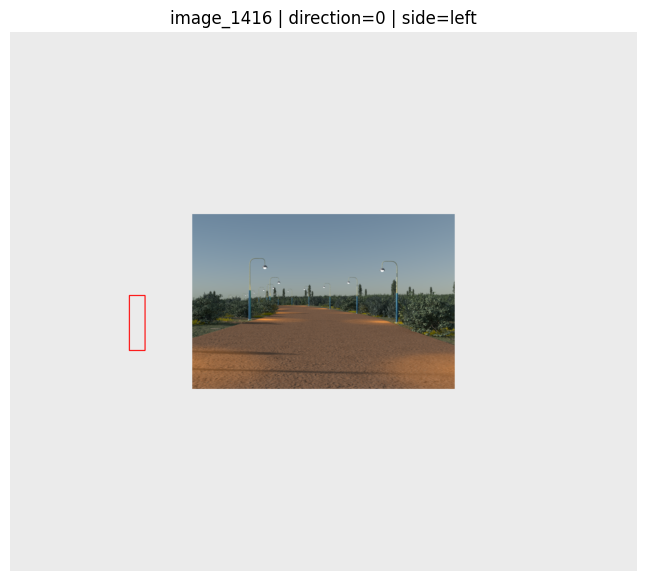

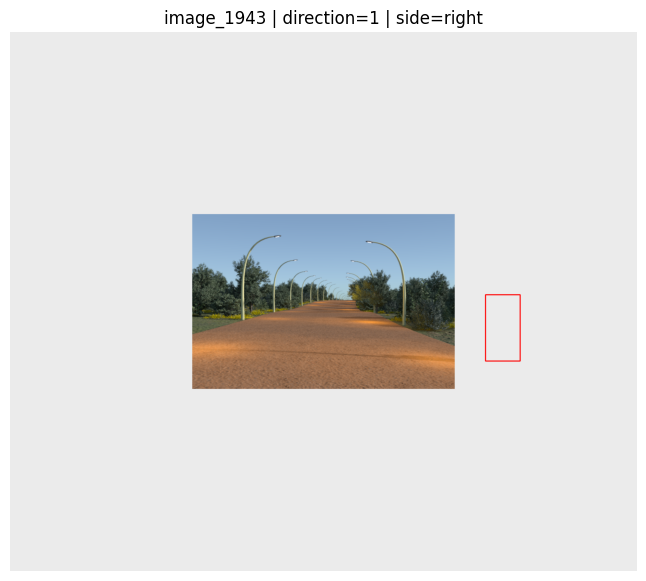

In [16]:
for idx in random.sample(range(len(df)), 5):
    show_extended_sample(df.iloc[idx], pad=500)

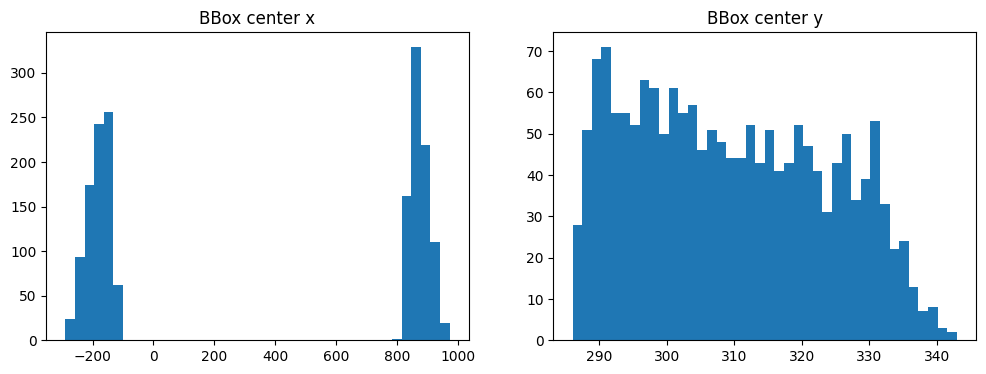

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["cx"], bins=40)
ax[0].set_title("BBox center x")

ax[1].hist(df["cy"], bins=40)
ax[1].set_title("BBox center y")

plt.show()

In [18]:
df[["xmin", "ymin", "xmax", "ymax", "bbox_width", "bbox_height", "cx", "cy", "direction"]].corr(numeric_only=True)

,xmin,ymin,xmax,ymax,bbox_width,bbox_height,cx,cy,direction
xmin,1.000000,-0.003648,0.998410,-0.022691,-0.029561,-0.020220,0.999602,-0.025554,-0.024201
ymin,-0.003648,1.000000,-0.005222,-0.796784,-0.027900,-0.835636,-0.004437,-0.744717,-0.047405
xmax,0.998410,-0.005222,1.000000,0.011120,0.026837,0.010690,0.999602,0.011575,-0.024397
ymax,-0.022691,-0.796784,0.011120,1.000000,0.599507,0.997734,-0.005788,0.996653,0.041701
bbox_width,-0.029561,-0.027900,0.026837,0.599507,1.000000,0.548065,-0.001364,0.658351,-0.003438
bbox_height,-0.020220,-0.835636,0.010690,0.997734,0.548065,1.000000,-0.004767,0.988893,0.043185
cx,0.999602,-0.004437,0.999602,-0.005788,-0.001364,-0.004767,1.000000,-0.006993,-0.024309
cy,-0.025554,-0.744717,0.011575,0.996653,0.658351,0.988893,-0.006993,1.000000,0.039643
direction,-0.024201,-0.047405,-0.024397,0.041701,-0.003438,0.043185,-0.024309,0.039643,1.000000


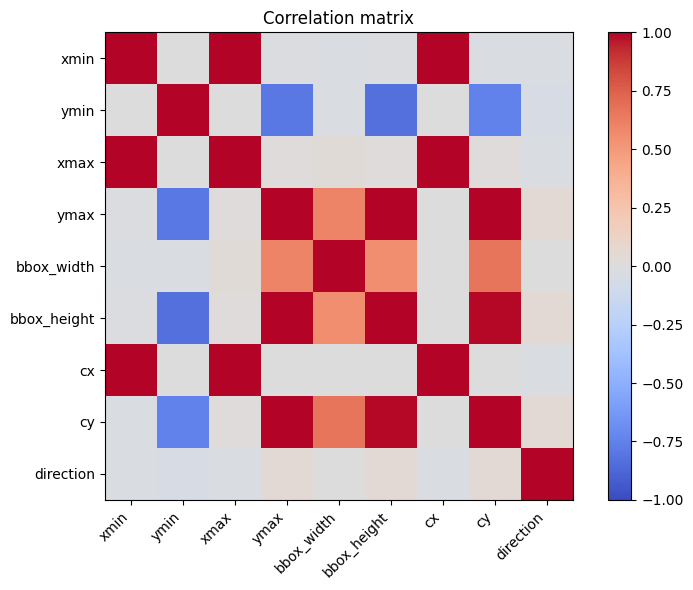

In [19]:
import matplotlib.pyplot as plt

corr = df[["xmin", "ymin", "xmax", "ymax", "bbox_width", "bbox_height", "cx", "cy", "direction"]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()